# China VLM

In [1]:
from settings_and_functions import *

# Examples of estimated distributions

Johnson SU parameters:
  gamma = 4.733
  delta = 2.488
  loc   = 11.971
  scale = 8.495
Johnson SU parameters:
  gamma = 4.448
  delta = 2.119
  loc   = 6.662
  scale = 3.061
Johnson SU parameters:
  gamma = 0.271
  delta = 0.907
  loc   = -0.484
  scale = 1.610


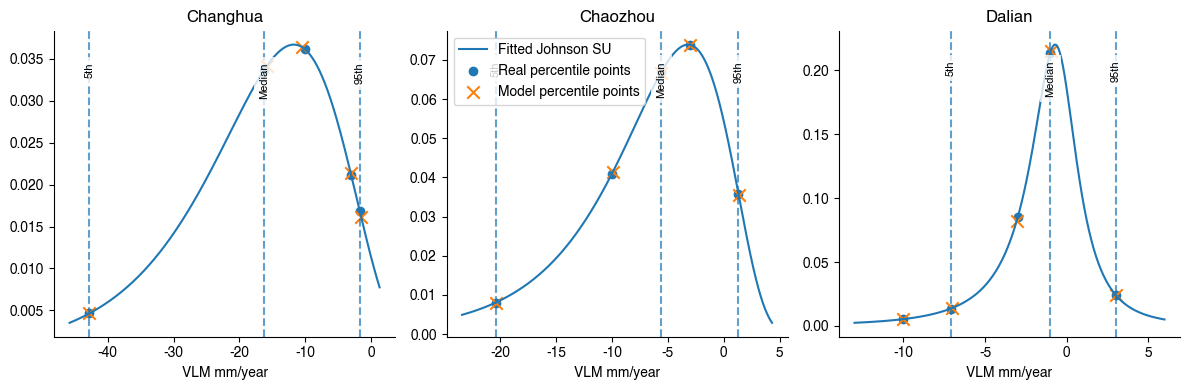

In [ ]:
dat = pd.read_csv(settings['data_in']+'/InSAR_China/' + 'InSAR_China.csv',delim_whitespace=True,names = ['Name','lat','lon','coastal',
                                                                                'f3','f10','med','5perc','95perc'])
ds_china = xr.Dataset(
    data_vars=dict(
        trend=(["x"], dat[dat['coastal']==1]['med']),
    ),
    coords=dict(
        lon=(["x"], dat[dat['coastal']==1]['lon']),
        lat=(["x"], dat[dat['coastal']==1]['lat']),
    ),
    )

fig, axs = plt.subplots(1, 3, figsize=(max_width, max_width/3))

for idx in range(3):
    row = dat[dat['coastal']==1].iloc[idx:idx+1]

    values = np.array([
        -3,
        -10,
        row['med'].values[0],
        row['5perc'].values[0],
        row['95perc'].values[0]
    ], dtype=float)

    percentiles = np.array([
        row['f3'].values[0],
        row['f10'].values[0],
        50,
        5,
        95
    ], dtype=float) / 100.0  # convert to [0,1]

    gamma_hat, delta_hat, loc_hat, scale_hat, estimated = fit_johnson_su(
        percentiles, values, make_plots=False
    )

    x = np.linspace(min(values) - 3, max(values) + 3, 400)
    pdf = johnsonsu.pdf(x, gamma_hat, delta_hat, loc=loc_hat, scale=scale_hat)
    ax = axs[idx]

    ax.plot(x, pdf, label="Fitted Johnson SU")

    # real percentile points
    y_real = johnsonsu.pdf(values, gamma_hat, delta_hat, loc=loc_hat, scale=scale_hat)
    ax.scatter(values, y_real, label="Real percentile points")

    # model percentile points
    y_est = johnsonsu.pdf(estimated, gamma_hat, delta_hat, loc=loc_hat, scale=scale_hat)
    ax.scatter(estimated, y_est, marker='x', s=80, label="Model percentile points")

    # ---------- NEW: vlines + text at 5th, median, 95th ----------
    # indices of 5%, 50%, 95% in your percentiles array
    idx_med = np.where(percentiles == 0.50)[0][0]
    idx_p5  = np.where(percentiles == 0.05)[0][0]
    idx_p95 = np.where(percentiles == 0.95)[0][0]

    # real values at those percentiles
    v5_real   = values[idx_p5]
    v50_real  = values[idx_med]
    v95_real  = values[idx_p95]

    # (optional) model values at those percentiles
    v5_model  = estimated[idx_p5]
    v50_model = estimated[idx_med]
    v95_model = estimated[idx_p95]

    # draw vlines for REAL percentiles
    for xv, lab in [(v5_real, '5th'), (v50_real, 'Median'), (v95_real, '95th')]:
        ax.axvline(xv, linestyle='--', alpha=0.7)
        ymax = ax.get_ylim()[1]
        ax.text(xv, ymax*0.9, lab, rotation=90,
                ha='center', va='top', fontsize=8,bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))


    ax.set_title(row['Name'].values[0])
    if idx == 1:
        ax.legend(loc='upper left')
    sns.despine()
    ax.set_xlabel('VLM mm/year')
    # ax.grid(True)

plt.tight_layout()
plt.show()


# Map on DIVA HR grid

In [ ]:
dat_info = pd.read_csv(settings['data_in']+'Nicholls2021/41558_2021_993_MOESM3_ESM.csv')

ds = xr.Dataset({'name': (['x'],  dat_info['locationid']),'test_val': (['x'],  [0] * len(dat_info['locationid'])) },
                coords={'lon': (['x'], dat_info['long']),
                'lat': (['x'], dat_info['lat']),
                'locationid': (['x'], dat_info['locationid'])}) 

all_interp =[]
limit=50
for x in ds_china.x.values:
    dst = copy.deepcopy(ds_china['trend'][x:x+1].to_dataset())

    row = dat[dat['coastal']==1].iloc[x:x+1]

    values = np.array([
        -3,
        -10,
        row['med'].values[0],
        row['5perc'].values[0],
        row['95perc'].values[0]
    ], dtype=float)

    percentiles = np.array([
        row['f3'].values[0],
        row['f10'].values[0],
        50,
        5,
        95
    ], dtype=float) / 100.0  # convert to [0,1]

    gamma_hat, delta_hat, loc_hat, scale_hat, estimated = fit_johnson_su(
        percentiles, values, make_plots=False
    )
    q25 = johnsonsu.ppf(0.25, gamma_hat, delta_hat, loc=loc_hat, scale=scale_hat)
    q50 = johnsonsu.ppf(0.50, gamma_hat, delta_hat, loc=loc_hat, scale=scale_hat)
    q75 = johnsonsu.ppf(0.75, gamma_hat, delta_hat, loc=loc_hat, scale=scale_hat)

    iqr = q75 - q25
    sigma_iqr = iqr / 1.3489795003921634  # normal-theory factor

    dst['trend_un']=dst['trend']*0+sigma_iqr
    dst['trend'].attrs['long_name'] = 'VLM China'

    #print(file)
    data = dst
    ds_sub = sl(ds).box([np.min(data['lon']).values-1.5,np.min(data['lon']).values+1.5,np.min(data['lat']).values-1.5,np.min(data['lat']).values+1.5]).data
    if len(ds_sub['name']) >2:
        if len(data.x) <= len(ds_sub['test_val']):       
            data_comb = []
            for i in range(1000):
                data_comb.append(data)
            data = xr.concat(data_comb,dim='x')  
        print(len(data.x) > len(ds_sub['test_val'])) 

        map_1_point,map_2_point = sl(data.x).couple(ds_sub['test_val'],limit=limit)
        out = map_1_point.data.dropna(dim='x')
        data_sel = data.isel(x =out.values.astype(int)  )
        out = out.rename('trend').to_dataset()
        out['trend'][:] =data_sel['trend'].values
        out['trend_un'] = copy.deepcopy(out['trend']*np.nan)
        out['trend_un'][:] =data_sel['trend_un'].values
        all_interp.append(out) 
new_data = []
for all_interp_val in all_interp:
    if 'time' in all_interp_val:
        all_interp_val = all_interp_val.drop('time')         
    new_data.append(all_interp_val)    
InSAR_China= xr.concat(new_data,dim='x')
InSAR_China.to_netcdf(settings['data_in']+'/InSAR_China/China_DIVA.nc')

Johnson SU parameters:
  gamma = 4.733
  delta = 2.488
  loc   = 11.971
  scale = 8.495
True
nearest
test_val
50
Johnson SU parameters:
  gamma = 4.448
  delta = 2.119
  loc   = 6.662
  scale = 3.061
True
nearest
test_val
50
Johnson SU parameters:
  gamma = 0.271
  delta = 0.907
  loc   = -0.484
  scale = 1.610
True
nearest
test_val
50
Johnson SU parameters:
  gamma = 0.112
  delta = 0.833
  loc   = 0.471
  scale = 1.898
True
nearest
test_val
50
Johnson SU parameters:
  gamma = 2.422
  delta = 1.303
  loc   = 1.375
  scale = 1.227
True
nearest
test_val
50
Johnson SU parameters:
  gamma = 3.082
  delta = 1.865
  loc   = 9.849
  scale = 5.948
True
nearest
test_val
50
Johnson SU parameters:
  gamma = 3.025
  delta = 1.148
  loc   = 2.228
  scale = 0.563
True
nearest
test_val
50
Johnson SU parameters:
  gamma = 1.747
  delta = 1.391
  loc   = 2.478
  scale = 2.447
True
nearest
test_val
50
Johnson SU parameters:
  gamma = 0.194
  delta = 0.678
  loc   = -0.945
  scale = 1.372
True
nearest
t